This notebook is for testing the Morlet decomposition of a signal. We will use the `scipy.signal.morlet` function to create a Morlet wavelet and then apply it to a sample signal.

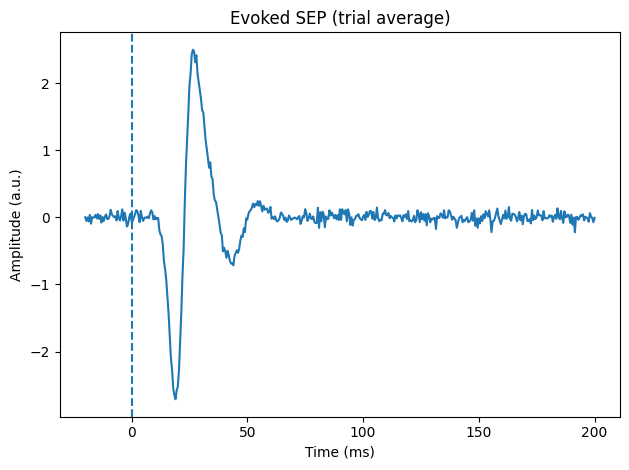

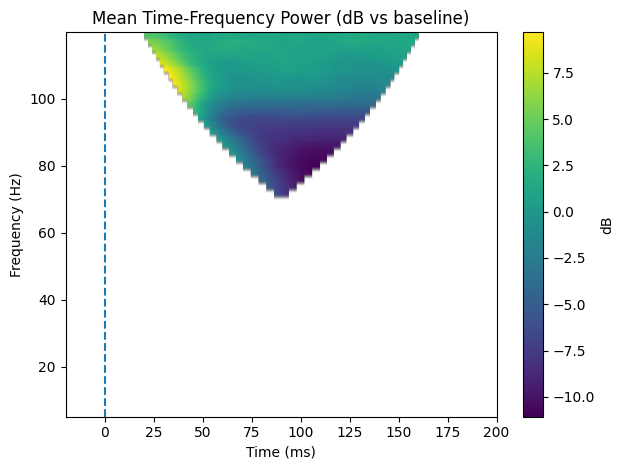

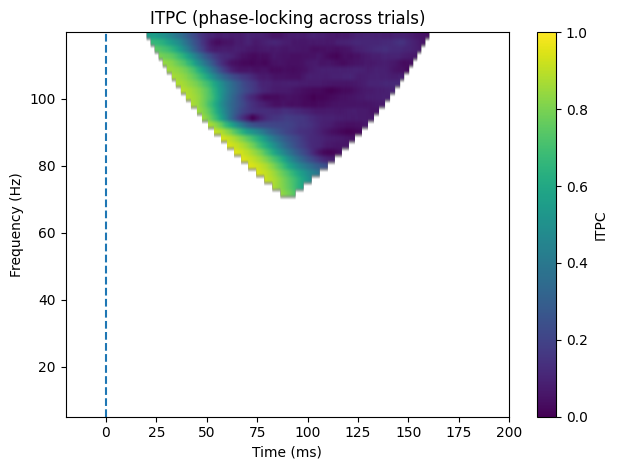

In [12]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt


# ----------------------------
# 1) Time axis + basic helpers
# ----------------------------
def make_time_vector(tmin_s: float, tmax_s: float, fs: float) -> np.ndarray:
    """Inclusive time vector from tmin to tmax with sampling rate fs."""
    n = int(round((tmax_s - tmin_s) * fs)) + 1
    return np.linspace(tmin_s, tmax_s, n, endpoint=True)

def next_pow_two(n: int) -> int:
    """Next power of 2 >= n (useful for FFT padding if you want)."""
    return 1 if n <= 1 else 2 ** int(np.ceil(np.log2(n)))


# --------------------------------------------
# 2) Complex Morlet wavelet creation functions
# --------------------------------------------
def create_wavelet(
        f_hz: float,
        fs: float,
        n_cycles: float = 6.0,
        t_support_sigma: float = 3.0,
) -> np.ndarray:
    """
    Create a complex Morlet wavelet at frequency f_hz.

    Parameters
    ----------
    f_hz : center frequency in Hz
    fs : sampling rate in Hz
    n_cycles : number of cycles (controls time/frequency tradeoff)
    t_support_sigma : wavelet half-support in units of sigma_t (3 => +/- 3*sigma_t)

    Returns
    -------
    wavelet : complex np.ndarray, time-domain wavelet normalized to unit energy
    """
    # Time spread (sigma_t) tied to cycles and frequency
    # sigma_t ≈ n_cycles / (2π f)
    sigma_t = n_cycles / (2 * np.pi * f_hz)

    # Build time vector for wavelet support: [-K*sigma_t, +K*sigma_t]
    tmax = t_support_sigma * sigma_t
    t = make_time_vector(-tmax, tmax, fs)

    # Complex Morlet (Gaussian-windowed complex sinusoid)
    sine = np.exp(1j * 2 * np.pi * f_hz * t)
    gauss = np.exp(-(t ** 2) / (2 * sigma_t ** 2))
    wavelet = sine * gauss

    # Normalize to unit energy so magnitudes are comparable across freqs
    wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))

    return wavelet


def make_wavelet_family(
        freqs_hz: np.ndarray,
        fs: float,
        n_cycles_fn,
        t_support_sigma: float = 3.0,
) -> list:
    """
    Create a list of wavelets (one per frequency).

    n_cycles_fn can be a function: f -> cycles
    """
    wavelets = []
    for f in freqs_hz:
        ncyc = float(n_cycles_fn(f))
        wavelets.append(create_wavelet(f, fs, n_cycles=ncyc, t_support_sigma=t_support_sigma))
    return wavelets


# -----------------------------------------
# 3) CWT via convolution (per trial, per f)
# -----------------------------------------
def cwt_single_trial(x: np.ndarray, wavelets: list) -> np.ndarray:
    """
    Compute complex CWT coefficients for one trial.

    Returns shape: (n_freqs, n_times)
    """
    n_times = x.size
    n_freqs = len(wavelets)
    W = np.zeros((n_freqs, n_times), dtype=np.complex128)

    for i, w in enumerate(wavelets):
        # Convolution with time-reversed conjugate wavelet is typical,
        # but for symmetric Morlet it mainly affects phase convention.
        # We'll use conjugate for standard correlation-like behavior.
        W[i, :] = fftconvolve(x, np.conj(w[::-1]), mode="same")

    return W


def cwt_trials(X: np.ndarray, wavelets: list) -> np.ndarray:
    """
    Compute complex CWT for all trials.

    X shape: (n_trials, n_times)
    Returns W shape: (n_trials, n_freqs, n_times)
    """
    n_trials, n_times = X.shape
    n_freqs = len(wavelets)
    W = np.zeros((n_trials, n_freqs, n_times), dtype=np.complex128)

    for k in range(n_trials):
        W[k] = cwt_single_trial(X[k], wavelets)

    return W


# ---------------------------------------
# 4) Metrics: power, evoked, ITPC, etc.
# ---------------------------------------
def compute_power(W: np.ndarray) -> np.ndarray:
    """Power = |W|^2. W shape: (trials, freqs, times) -> power same shape."""
    return np.abs(W) ** 2


def compute_itpc(W: np.ndarray) -> np.ndarray:
    """
    Inter-trial phase coherence (ITPC).

    ITPC(f,t) = | mean_k exp(i*phase_k(f,t)) |
    W shape: (trials, freqs, times)
    Returns: (freqs, times)
    """
    phase = np.angle(W)
    itpc = np.abs(np.mean(np.exp(1j * phase), axis=0))
    return itpc


def baseline_normalize_db(
        P: np.ndarray,
        t: np.ndarray,
        baseline: tuple = (-0.02, -0.005),
        eps: float = 1e-12,
) -> np.ndarray:
    """
    Baseline normalize power in dB relative to baseline mean.

    P shape: (trials, freqs, times) OR (freqs, times)
    """
    b0, b1 = baseline
    bmask = (t >= b0) & (t <= b1)

    if P.ndim == 3:
        # trial-wise baseline mean for each trial & freq
        bmean = np.mean(P[:, :, bmask], axis=2, keepdims=True)
        Pdb = 10 * np.log10((P + eps) / (bmean + eps))
    elif P.ndim == 2:
        bmean = np.mean(P[:, bmask], axis=1, keepdims=True)
        Pdb = 10 * np.log10((P + eps) / (bmean + eps))
    else:
        raise ValueError("P must have 2 or 3 dimensions.")
    return Pdb


def apply_coi_mask(
        TFR: np.ndarray,
        t: np.ndarray,
        freqs_hz: np.ndarray,
        n_cycles_fn,
        fs: float,
        sigma_support: float = 3.0,
        fill_value=np.nan,
) -> np.ndarray:
    """
    Mask time points near edges where wavelet support extends beyond epoch.

    Edge width approx: sigma_support * sigma_t(f), where sigma_t = n_cycles/(2πf)
    """
    TFRm = TFR.copy()
    tmin, tmax = t[0], t[-1]

    for i, f in enumerate(freqs_hz):
        sigma_t = float(n_cycles_fn(f)) / (2 * np.pi * f)
        edge = sigma_support * sigma_t
        valid = (t >= (tmin + edge)) & (t <= (tmax - edge))
        if TFRm.ndim == 2:
            TFRm[i, ~valid] = fill_value
        elif TFRm.ndim == 3:
            TFRm[:, i, ~valid] = fill_value
        else:
            raise ValueError("TFR must have 2 or 3 dimensions.")
    return TFRm


# ---------------------------------------
# 5) Example SEP-like data (replace with yours)
# ---------------------------------------
def simulate_sep_trials(
        n_trials: int,
        t: np.ndarray,
        fs: float,
        noise_sd: float = 1.0,
        n20_ms: float = 0.020,
        p25_ms: float = 0.025,
        amp_n20: float = -4.0,
        amp_p25: float = 3.0,
        jitter_ms: float = 0.8,
) -> np.ndarray:
    """
    Simple synthetic SEP: two Gaussians (N20/P25) + noise.
    Units arbitrary (e.g., microvolts-like).
    """
    rng = np.random.default_rng(0)
    X = noise_sd * rng.standard_normal((n_trials, t.size))

    def gauss(t, mu, sd):
        return np.exp(-0.5 * ((t - mu) / sd) ** 2)

    n20 = n20_ms
    p25 = p25_ms

    for k in range(n_trials):
        jitter = rng.normal(0, jitter_ms / 1000.0)
        # Narrow-ish peaks, SEP-like
        X[k] += amp_n20 * gauss(t, n20 + jitter, 0.003)
        X[k] += amp_p25 * gauss(t, p25 + jitter, 0.004)

        # Optional little 40 Hz burst around 20–60 ms
        burst_mask = (t >= 0.020) & (t <= 0.060)
        X[k, burst_mask] += 0.7 * np.sin(2 * np.pi * 40 * t[burst_mask]) * gauss(t[burst_mask], 0.040 + jitter, 0.010)

    return X


# ---------------------------------------
# 6) Main analysis script
# ---------------------------------------

# Epoch: -20 ms to 200 ms
fs = 2000.0
t = make_time_vector(-0.020, 0.200, fs)

# Data: shape (300, n_times)
X = simulate_sep_trials(n_trials=300, t=t, fs=fs)
# If you have real data, do:
# X = your_data_array  # shape (300, len(t))

# (Optional) remove DC per trial (common)
X = X - np.mean(X[:, t < 0], axis=1, keepdims=True)

# Frequency grid for SEP time-frequency
fmin, fmax = 5.0, 120.0
    voices_per_octave = 12
    n_steps = int(np.floor(voices_per_octave * np.log2(fmax / fmin))) + 1
    freqs_hz = fmin * (2 ** (np.arange(n_steps) / voices_per_octave))

    # Cycles schedule: good SEP default (more time precision at low f, more freq precision at high f)
    def n_cycles_fn(f):
        # smoothly increases from ~3 at 5 Hz to ~10 at 120 Hz
        return 3.0 + (10.0 - 3.0) * (np.log(f / fmin) / np.log(fmax / fmin))

    # Create wavelet family
    wavelets = make_wavelet_family(freqs_hz, fs, n_cycles_fn, t_support_sigma=3.0)

    # Compute CWT
    W = cwt_trials(X, wavelets)  # (trials, freqs, times)

    # Power + baseline normalization
    P = compute_power(W)                         # (trials, freqs, times)
    Pdb = baseline_normalize_db(P, t, baseline=(-0.020, -0.005))  # use most of pre-stim

    # Trial-averaged power (total power)
    mean_Pdb = np.mean(Pdb, axis=0)              # (freqs, times)

    # ITPC
    itpc = compute_itpc(W)                       # (freqs, times)

    # Mask edges (cone of influence-ish)
    mean_Pdb_m = apply_coi_mask(mean_Pdb, t, freqs_hz, n_cycles_fn, fs, sigma_support=3.0)
    itpc_m = apply_coi_mask(itpc, t, freqs_hz, n_cycles_fn, fs, sigma_support=3.0)

    # Also compute the time-domain evoked SEP (average over trials)
    evoked = np.mean(X, axis=0)

    # -----------------
    # Plotting results
    # -----------------
    # 1) Evoked SEP
    plt.figure()
    plt.plot(t * 1000, evoked)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (a.u.)")
    plt.title("Evoked SEP (trial average)")
    plt.tight_layout()

    # 2) Time-frequency power (dB)
    plt.figure()
    plt.imshow(
        mean_Pdb_m,
        aspect="auto",
        origin="lower",
        extent=[t[0] * 1000, t[-1] * 1000, freqs_hz[0], freqs_hz[-1]],
    )
    plt.axvline(0, linestyle="--")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Mean Time-Frequency Power (dB vs baseline)")
    plt.colorbar(label="dB")
    plt.tight_layout()

    # 3) ITPC
    plt.figure()
    plt.imshow(
        itpc_m,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
        extent=[t[0] * 1000, t[-1] * 1000, freqs_hz[0], freqs_hz[-1]],
    )
    plt.axvline(0, linestyle="--")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (Hz)")
    plt.title("ITPC (phase-locking across trials)")
    plt.colorbar(label="ITPC")
    plt.tight_layout()

    plt.show()




Now we are going to define a function that creates a family of Morlet wavelets across a range of frequencies. This will allow us to perform a time-frequency decomposition of a signal. The parameters will include the sampling rate, the range of frequencies, the number of cycles for each wavelet,  whether to normalize the wavelets, and sigma for

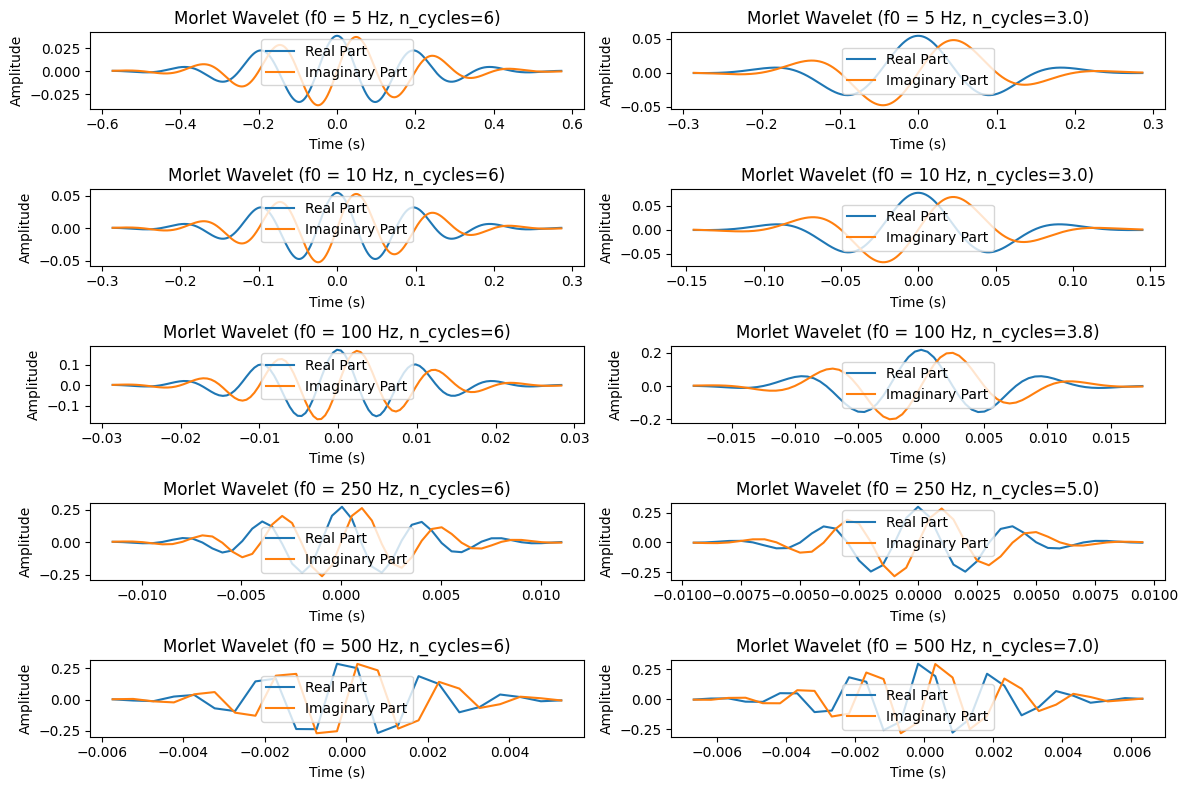

In [9]:
import numpy as np

def make_morlet_family(fs, freqs, n_cycles=6, normalize=True):
    """
    freqs: array-like center frequencies in Hz
    returns: list of dicts: [{'f0':..., 't':..., 'w':...}, ...]
    """
    family = []
    for f0 in freqs:
        t, w = morlet_wavelet(fs, f0, n_cycles=n_cycles, normalize=normalize)
        family.append({"f0": f0, "t": t, "w": w})
    return family

# Example frequency grids
fs = 256

# Log-spaced is common for EEG (more resolution at low freqs)
freqs_log = np.logspace(np.log10(2), np.log10(40), 30)  # 2–40 Hz, 30 steps

# Or linear
freqs_lin = np.linspace(2, 40, 39)

family = make_morlet_family(fs, freqs_log, n_cycles=6)


def make_morlet_family_variable_cycles(fs, freqs, cycles_low=3, cycles_high=10, normalize=True):
    freqs = np.asarray(freqs)
    # linearly ramp cycles across frequency range (simple + effective)
    n_cycles = np.interp(freqs, (freqs.min(), freqs.max()), (cycles_low, cycles_high))

    family = []
    for f0, nc in zip(freqs, n_cycles):
        t, w = morlet_wavelet(fs, f0, n_cycles=float(nc), normalize=normalize)
        family.append({"f0": float(f0), "n_cycles": float(nc), "t": t, "w": w})
    return family

family_var = make_morlet_family_variable_cycles(fs, freqs_log, cycles_low=3, cycles_high=12)


# test both functions by plotting the wavelets for a few frequencies (5 to 500 in steps of 100)
fs = 2000
test_freqs = [5, 10, 100, 250, 500]
family_test = make_morlet_family(fs, test_freqs, n_cycles=6)
family_var_test = make_morlet_family_variable_cycles(fs, test_freqs, cycles_low=3, cycles_high=7)
plt.figure(figsize=(12, 8))
for i, f0 in enumerate(test_freqs):
    plt.subplot(len(test_freqs), 2, 2*i+1)
    plt.plot(family_test[i]['t'], family_test[i]['w'].real, label='Real Part')
    plt.plot(family_test[i]['t'], family_test[i]['w'].imag, label='Imaginary Part')
    plt.title(f'Morlet Wavelet (f0 = {f0} Hz, n_cycles=6)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.subplot(len(test_freqs), 2, 2*i+2)
    plt.plot(family_var_test[i]['t'], family_var_test[i]['w'].real, label='Real Part')
    plt.plot(family_var_test[i]['t'], family_var_test[i]['w'].imag, label='Imaginary Part')
    plt.title(f'Morlet Wavelet (f0 = {f0} Hz, n_cycles={family_var_test[i]["n_cycles"]:.1f})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
plt.tight_layout()
plt.show()